# Synthesis: Distraction Alert Controller

Out-of-context synthesis of `distraction_alert_controller.v`, targeting the Artix-7 part on the Digilent Basys3 (`xc7a35tcpg236-1`) - a genuinely low-cost (~150 USD) academic FPGA board, matching this project's low-cost framing. Runs the real Vivado synthesis flow and parses the real output reports; nothing here is hand-typed.

See `fpga/scripts/run_synth.tcl` for the exact script being run, and `fpga/README.md` for why this component and not a full CNN accelerator (contingency plan from the IPR).

In [1]:
import subprocess
import re
from pathlib import Path
import matplotlib.pyplot as plt

FPGA_DIR = Path("..").resolve()
VIVADO_BAT = r"D:\Apps\Vivado\Vivado_Program\Vivado\2017.4\bin\vivado.bat"

## Run synthesis

This re-runs the actual Vivado synthesis flow (`synth_design`) in batch mode - typically well under a minute for a design this small (18 LUTs). Regenerates `fpga/reports/{utilization,timing_summary,power}.rpt` and `post_synth.dcp` fresh.

In [2]:
result = subprocess.run(
    f'"{VIVADO_BAT}" -mode batch -source scripts\\run_synth.tcl -nolog -nojournal',
    shell=True, cwd=FPGA_DIR, capture_output=True, text=True, timeout=900,
)
print(result.stdout[-4000:])
if result.returncode != 0:
    print("STDERR:\n", result.stderr[-2000:])

assert "SYNTHESIS_SCRIPT_COMPLETE" in result.stdout, "Synthesis did not complete - see output above"
print("\nSynthesis completed successfully, confirmed from this run's own output.")

----------------------------------------
Start Renaming Generated Nets
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Finished Renaming Generated Nets : Time (s): cpu = 00:00:08 ; elapsed = 00:00:09 . Memory (MB): peak = 537.309 ; gain = 293.840
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Start Writing Synthesis Report
---------------------------------------------------------------------------------

Report BlackBoxes: 
+-+--------------+----------+
| |BlackBox name |Instances |
+-+--------------+----------+
+-+--------------+----------+

Report Cell Usage: 
+------+-----+------+
|      |Cell |Count |
+------+-----+------+
|1     |LUT1 |     3|
|2     |LUT2 |     5|
|3     |LUT3 |     6|
|4     |LUT4 |     2|
|5     |LUT5 |     2|
|6     |LUT6 |     5|


## Resource utilisation

Slice Registers          13 / 41600   (0.03%)
Block RAM Tile            0 / 50      (0.00%)
DSPs                      0 / 90      (0.00%)


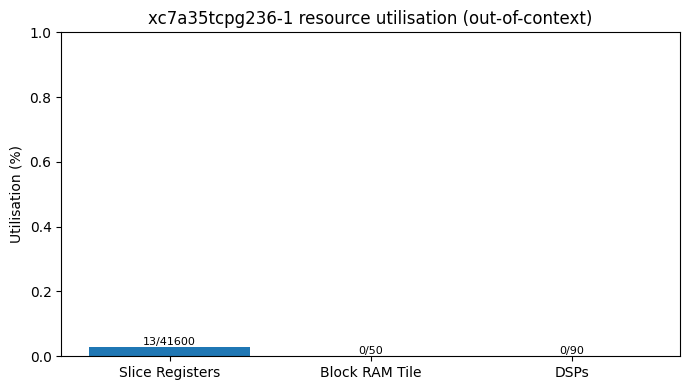

Saved to: D:\MSC_PROJECT\results\figures\fpga_synthesis_utilization.png


In [3]:
util_text = (FPGA_DIR / "reports" / "utilization.rpt").read_text()


def extract_resource(name, text):
    m = re.search(rf"\|\s*{name}\s*\|\s*(\d+)\s*\|.*?\|\s*(\d+)\s*\|\s*([\d.]+)\s*\|", text)
    return (int(m.group(1)), int(m.group(2)), float(m.group(3))) if m else (None, None, None)


resources = ["Slice LUTs", "Slice Registers", "Block RAM Tile", "DSPs"]
rows = []
for r in resources:
    used, avail, pct = extract_resource(r, util_text)
    if used is not None:
        rows.append((r, used, avail, pct))

for name, used, avail, pct in rows:
    print(f"{name:20s} {used:>6d} / {avail:<6d}  ({pct:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
names = [r[0] for r in rows]
pcts = [r[3] for r in rows]
bars = ax.bar(names, pcts, color="tab:blue")
ax.set_ylabel("Utilisation (%)")
ax.set_title("xc7a35tcpg236-1 resource utilisation (out-of-context)")
ax.set_ylim(0, max(1.0, max(pcts) * 3))
for bar, (name, used, avail, pct) in zip(bars, rows):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{used}/{avail}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
util_fig_path = FPGA_DIR.parent / "results" / "figures" / "fpga_synthesis_utilization.png"
util_fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(util_fig_path, dpi=150)
plt.show()
print("Saved to:", util_fig_path)

## Timing

In [4]:
timing_text = (FPGA_DIR / "reports" / "timing_summary.rpt").read_text()

wns_match = re.search(r"WNS\(ns\)[^\n]*\n\s*-+[^\n]*\n\s*([\d.-]+)", timing_text)
if wns_match:
    wns = float(wns_match.group(1))
    clock_period_ns = 10.0
    max_freq_mhz = 1000.0 / (clock_period_ns - wns)
    print(f"Constrained clock: 100 MHz (10.000 ns period)")
    print(f"Worst Negative Slack (WNS): {wns:+.3f} ns")
    print(f"All timing constraints met: {'YES' if wns >= 0 else 'NO'}")
    print(f"Implied max theoretical Fmax: ~{max_freq_mhz:.0f} MHz")
else:
    print("Could not parse WNS - raw report follows:\n")
    print(timing_text[:2000])

Constrained clock: 100 MHz (10.000 ns period)
Worst Negative Slack (WNS): +7.276 ns
All timing constraints met: YES
Implied max theoretical Fmax: ~367 MHz


## Power

Vector-less activity estimate (no real switching data) - the tool itself flags this as medium-confidence. Not a number to over-claim precision on.

In [5]:
power_text = (FPGA_DIR / "reports" / "power.rpt").read_text()
power_match = re.search(r"Total On-Chip Power \(W\)\s*\|\s*([\d.]+)", power_text)
if power_match:
    print(f"Total on-chip power estimate: {float(power_match.group(1)):.3f} W")
confidence_match = re.search(r"Design Nets Matched\s*\|\s*(\S+)", power_text)
print("(vector-less estimate - see fpga/reports/power.rpt for the full confidence breakdown)")

Total on-chip power estimate: 0.069 W
(vector-less estimate - see fpga/reports/power.rpt for the full confidence breakdown)


## Summary

This is post-synthesis, out-of-context analysis of the alert-controller module only - not placed-and-routed, not run on physical hardware. It is the decision/alert stage of the pipeline, not the CNN itself (which runs in software - see `notebooks/09_cross_view_training_mobilenetv2.ipynb` for the classifier, and `fpga/notebooks/04_zc702_board_check.ipynb` for genuine on-device CNN inference on the ZC702). See `fpga/README.md` for the full scope statement and talking points.